# Data Analytics I — Linear Regression on Boston Housing Dataset

**Objective:** Predict home prices (MEDV) using Linear Regression.

**Dataset:** Boston Housing — 506 samples, 14 features.
**Source:** https://www.kaggle.com/c/boston-housing

## Step 1: Import Libraries

In [5]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split — splits data into training and testing sets
from sklearn.model_selection import train_test_split

# LinearRegression — the regression model
from sklearn.linear_model import LinearRegression

# Metrics to evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

## Step 2: Load the Dataset

In [6]:
# Load the Boston Housing dataset from CSV
df = pd.read_csv('Linear_Regression_Boston_IV.csv')

# Check shape and first rows
print("Shape:", df.shape)
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.68937,50.0,26.21,0,0.589,6.947,8.4,3.7423,3,215.0,21.1,208.70,29.15,37.3
1,10.83644,25.0,1.54,0,0.511,6.639,50.6,1.6758,1,538.0,19.6,43.74,5.18,48.0
2,4.74028,75.0,19.71,0,0.740,6.788,92.9,9.1006,5,308.0,17.6,80.77,2.73,50.0
3,3.28659,12.5,25.70,1,0.862,6.641,13.1,2.3575,1,315.0,20.7,396.23,16.36,35.1
4,0.61065,0.0,5.39,0,0.510,5.831,77.1,7.8215,1,347.0,19.1,215.01,37.74,32.0


In [7]:
# Column descriptions:
# CRIM    - per capita crime rate by town
# ZN      - proportion of residential land zoned for large lots
# INDUS   - proportion of non-retail business acres
# CHAS    - Charles River dummy variable (1 if tract bounds river)
# NOX     - nitric oxides concentration
# RM      - average number of rooms per dwelling
# AGE     - proportion of owner-occupied units built before 1940
# DIS     - weighted distance to employment centers
# RAD     - index of accessibility to radial highways
# TAX     - property tax rate per $10,000
# PTRATIO - pupil-teacher ratio
# B       - proportion of Black residents (historical variable)
# LSTAT   - % lower status of the population
# MEDV    - median value of owner-occupied homes in $1000s (TARGET)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Step 3: Check for Missing Values

In [8]:
# isnull().sum() counts missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [9]:
# describe() — summary statistics for all numeric columns
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.610698,11.783597,14.497905,0.071146,0.630397,6.279202,50.641700,6.523078,7.132411,449.148221,17.232016,192.315850,20.159862,41.305138
std,3.491683,23.503067,8.110230,0.257323,0.138998,0.669470,27.676152,3.198580,6.863900,147.188718,2.734402,118.019181,10.330352,8.044954
min,0.018270,0.000000,0.590000,0.000000,0.386000,4.166000,3.000000,1.130300,1.000000,188.000000,12.600000,0.570000,1.780000,16.200000
25%,0.997000,0.000000,6.992500,0.000000,0.519250,5.820500,25.250000,3.792650,3.000000,322.250000,15.000000,86.482500,11.382500,35.900000
50%,2.606975,0.000000,14.985000,0.000000,0.631500,6.283000,50.500000,6.371250,5.000000,451.000000,17.200000,189.520000,20.355000,42.600000
75%,5.067795,12.500000,21.487500,0.000000,0.749750,6.754750,75.575000,9.212075,7.000000,576.500000,19.600000,291.670000,28.187500,49.775000
max,17.844580,100.000000,27.720000,1.000000,0.870000,8.457000,100.000000,12.081300,24.000000,709.000000,22.000000,396.230000,37.960000,50.000000


## Step 4: Exploratory Data Analysis

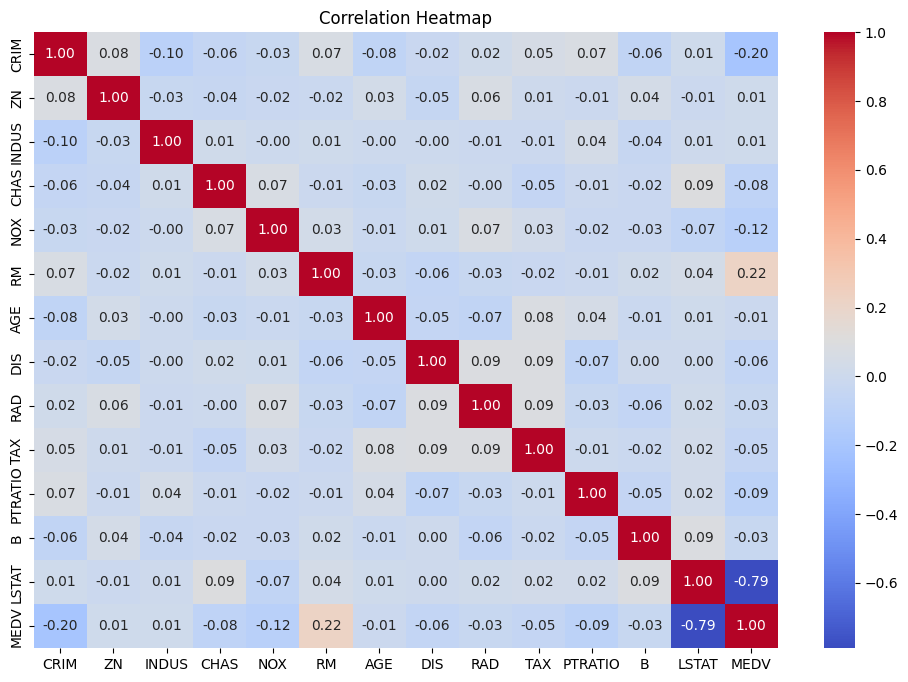

In [10]:
# Correlation matrix — measures linear relationship between features
# Values range from -1 (strong negative) to +1 (strong positive)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# Correlation of each feature with the target (MEDV)
# Features with high |correlation| are most useful for prediction
print("Correlation with MEDV (target):")
print(df.corr()['MEDV'].sort_values(ascending=False))

Correlation with MEDV (target):
MEDV       1.000000
RM         0.223811
INDUS      0.010202
ZN         0.010086
AGE       -0.011737
RAD       -0.032054
B         -0.034207
TAX       -0.048917
DIS       -0.058746
CHAS      -0.080431
PTRATIO   -0.090814
NOX       -0.117376
CRIM      -0.203032
LSTAT     -0.790049
Name: MEDV, dtype: float64


## Step 5: Prepare Features (X) and Target (y)

In [12]:
# X = all feature columns (drop MEDV — that's the target)
X = df.drop('MEDV', axis=1)

# y = target variable (what we want to predict)
y = df['MEDV']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (506, 13)
y shape: (506,)


## Step 6: Split into Training and Testing Sets

In [13]:
# train_test_split:
#   test_size=0.2  -> 80% training, 20% testing
#   random_state=42 -> reproducible split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (404, 13) (404,)
Testing set: (102, 13) (102,)


## Step 7: Train the Linear Regression Model

In [14]:
# Create the model object
model = LinearRegression()

# fit() trains the model on the training data
# It learns the coefficients (weights) for each feature
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Intercept (b0):", round(model.intercept_, 4))

Model trained successfully.
Intercept (b0): 48.3268


In [15]:
# coef_ contains the learned coefficient for each feature
# A positive coefficient => feature increases price; negative => decreases price
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Feature coefficients:")
coefficients

Feature coefficients:


,Feature,Coefficient
5,RM,2.944694
3,CHAS,0.049593
1,ZN,0.009604
8,RAD,0.006817
11,B,0.001424
9,TAX,-0.000374
6,AGE,-0.000709
2,INDUS,-0.013508
7,DIS,-0.103907
10,PTRATIO,-0.199345


## Step 8: Make Predictions

In [16]:
# predict() applies the trained model to the test set
y_pred = model.predict(X_test)

# Compare predicted vs actual for the first 10 test samples
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(2)
})
comparison

,Actual,Predicted
0,41.9,43.60
1,28.6,32.77
2,40.2,41.94
3,45.3,40.75
4,50.0,53.70
5,46.6,42.40
6,46.9,37.92
7,34.9,38.66
8,35.3,38.13
9,37.2,38.12


## Step 9: Evaluate the Model

In [17]:
# MAE  — Mean Absolute Error: average absolute difference (same units as target)
# MSE  — Mean Squared Error: penalizes larger errors more
# RMSE — Root Mean Squared Error: same units as target, easier to interpret
# R²   — coefficient of determination: % of variance explained by the model (closer to 1 is better)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"Mean Absolute Error  (MAE):  {mae:.4f}")
print(f"Mean Squared Error   (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²) Score:        {r2:.4f}")

Mean Absolute Error  (MAE):  3.3045
Mean Squared Error   (MSE):  17.4305
Root Mean Squared Error (RMSE): 4.1750
R-squared (R²) Score:        0.7251


## Step 10: Visualize Results

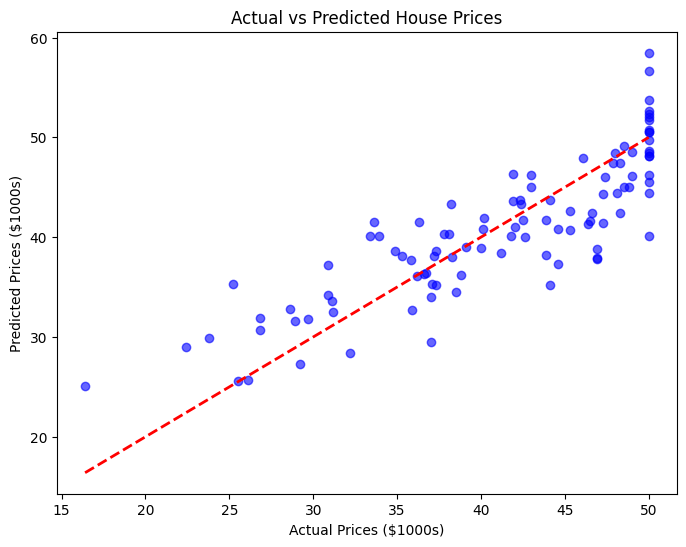

In [18]:
# Scatter plot: Actual vs Predicted
# Points close to the red diagonal line = good predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices ($1000s)')
plt.ylabel('Predicted Prices ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.show()

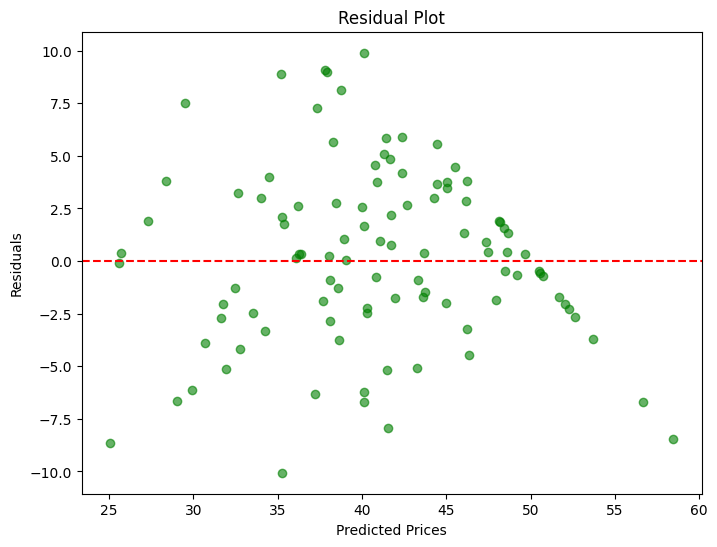

In [15]:
# Residual plot — residuals = actual − predicted
# Should be randomly scattered around 0 (no clear pattern)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

## Conclusion

We built a Linear Regression model to predict Boston home prices.

**Workflow:** Load → Explore → Split → Train (`fit`) → Predict (`predict`) → Evaluate (MAE, MSE, RMSE, R²).

The R² score tells us how much of the variation in house prices the model can explain. Residual plot helps verify the linear regression assumptions hold.

Sure — here's the same plain-English walkthrough for the Linear Regression notebook.

---

## Data Analytics I — Linear Regression on Boston Housing Dataset

**Big picture:** Build a **predictive model** that takes information about a house (number of rooms, crime rate in the area, distance from job centers, etc.) and outputs a guess for what that house would sell for. This is the first notebook where we move from *describing* data to actually *predicting* something from it.

**The core idea of Linear Regression:** Find the straight-line relationship between input features and a target number. The model learns a "weight" for each feature that says how much the price should change when that feature changes by one unit. For example, it might learn that "every additional room adds about $4,000 to the price" or "every 1% increase in lower-status population reduces the price by about $800."

**What we did, step by step:**

1. **Brought in our toolbox** — Loaded pandas and numpy for data handling, matplotlib and seaborn for plotting, and from scikit-learn we pulled in:
   - The **train/test splitter** — divides our data into two pieces.
   - The **Linear Regression model** itself.
   - **Evaluation metrics** — formulas for measuring how good our predictions are.

2. **Loaded the dataset** — Read the Boston Housing CSV: 506 houses, 14 columns. Thirteen of those columns are *features* (things we know about each house) and one is the *target* — `MEDV`, the median home price in thousands of dollars.

3. **Documented every column** — Wrote out what each feature represents (crime rate, average rooms, pupil-teacher ratio, etc.) so anyone reading the notebook understands what the model is using.

4. **Sanity-checked the data:**
   - Confirmed there are no missing values.
   - Got summary statistics (mean, min, max, spread) for every column to spot anything weird.

5. **Explored relationships between features and price:**
   - **Correlation heatmap** — a colored grid showing how strongly each pair of variables moves together. Numbers close to +1 (red) mean "they go up together"; close to −1 (blue) mean "one goes up, the other goes down"; close to 0 means "no linear relationship."
   - **Sorted correlations with the target** — ranked all 13 features by how strongly they correlate with house price. This tells us which features are likely to be the best predictors. (For Boston, `RM` — average rooms — is usually the strongest positive predictor; `LSTAT` — lower-status population — is usually the strongest negative one.)

6. **Separated the inputs from the output** — Built two pieces:
   - **X** = the 13 feature columns (what the model gets to *see*).
   - **y** = the price column (what the model has to *predict*).

7. **Split into training and test sets** — This is *the* fundamental rule of supervised machine learning: **never test a model on the same data it was trained on**. We held back 20% of the houses as a "test set" the model never gets to see during training. The other 80% became the "training set" the model learns from. The test set acts as a stand-in for "future, unseen houses" so we can honestly measure how well the model generalizes.

8. **Trained the model** — Fed the training features and prices to Linear Regression and asked it to find the best straight-line equation:
   `Price = b₀ + b₁·feature₁ + b₂·feature₂ + ... + b₁₃·feature₁₃`
   The model figured out the values of all the b's that minimize the average squared error on the training data.
   - **Intercept (b₀)** — what the model predicts when all features are zero (the "starting point").
   - **Coefficients (b₁ through b₁₃)** — the learned weight for each feature. A positive coefficient means more of that feature pushes price *up*; a negative coefficient pushes it *down*.

9. **Made predictions on the test set** — Asked the trained model to predict prices for the 20% of houses it had never seen. Compared the predicted prices side-by-side with the actual prices for the first ten test houses to get an intuitive feel for how close the predictions were.

10. **Measured how good the model is** — Used four standard metrics:

    - **MAE (Mean Absolute Error)** — On average, how many thousand dollars off was each prediction? Easiest to interpret because it's in the same units as the target.

    - **MSE (Mean Squared Error)** — Same idea, but errors are squared before averaging. This penalizes *big* errors more than small ones — being off by $10K hurts much more than being off by $1K.

    - **RMSE (Root Mean Squared Error)** — The square root of MSE, which brings the units back to thousands of dollars. Like MAE but more sensitive to large errors.

    - **R² (R-squared / coefficient of determination)** — The headline score. Tells you what fraction of the variation in house prices the model can explain. Ranges from 0 to 1 (sometimes negative for terrible models).
       - 1.0 = perfect predictions
       - 0.7 = the model explains 70% of the price variation; the remaining 30% is noise or factors we don't have data for
       - 0.0 = the model is no better than just guessing the average price every time

11. **Visualized the results — two important plots:**

    - **Actual vs Predicted scatter plot** — Each dot is one test house: its real price on the x-axis, the model's prediction on the y-axis. The red diagonal line is "perfect prediction." The closer the dots cluster to that line, the better the model. Big spreads above or below the line mean systematic errors.

    - **Residual plot** — A "residual" is just `actual − predicted` (how far off each prediction was). Plotting residuals against predicted values is a *diagnostic* tool. What we want: a random cloud of dots scattered evenly around zero with no pattern. What we *don't* want:
       - A funnel shape (errors grow with price → variance isn't constant)
       - A curve (the relationship isn't actually linear → linear regression is the wrong model)
       - Most dots on one side of zero (systematic over- or under-prediction)

12. **Concluded** — The model gives a respectable R² and reasonable error, but you can see from the residuals where it struggles (typically with very expensive houses, since the dataset caps prices at $50K). For a more accurate model you'd consider non-linear methods like Random Forests or XGBoost — but Linear Regression is the right *starting point* because it's simple, fast, and interpretable: you can literally read off how much each feature contributes to the price.

---

### How this notebook connects to the previous three

The earlier three notebooks built up to this:

- **Data Wrangling I** — got the data structurally clean (no missing values, all numeric).
- **Data Wrangling II** — got the data statistically well-behaved (no outliers, no skewness).
- **Descriptive Statistics** — *understood* the data through summary stats.
- **Linear Regression (this notebook)** — finally *used* the cleaned, understood data to make predictions.

In a real project you'd run all three preparation steps on your raw data first, then feed the result into a model like this one. The Boston dataset happens to come pre-cleaned, so we skipped most of the wrangling — but on a messy real-world dataset, those three steps would be 80% of the work and the modeling step would be the easy part at the end.